# Cross-Validation Results Analysis

This notebook collects results from DDH experiments and identifies the best performing models based on validation metrics.


In [1]:
import json
import os
import pandas as pd
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# ── Change this to select the dataset ──────────────────────────────────────
DATASET = 'churn_lastfm_months'   # 'nasa' | 'big_rw' | 'mimic' | 'churn_lastfm_months'
# ───────────────────────────────────────────────────────────────────────────


In [2]:
def collect_results(base_path="../DDH"):
    """
    Simple function to collect all results from JSON files.
    """
    results = []
    
    algorithms = {
        'DDH_results_TC': 'DDH_TC',
        'DDH_results': 'DDH', 
    }
    
    datasets = ['nasa', 'mimic', 'big_rw', 'churn_lastfm_months']
    
    # Find all DDH_results folders
    ddh_folders = []
    for folder in os.listdir(base_path):
        if folder.startswith("DDH_results") and not folder.endswith("_previous"):
            ddh_folders.append(os.path.join(base_path, folder))
    
    print(f"Found DDH results folders: {[os.path.basename(f) for f in ddh_folders]}")
    
    # Collect results
    for ddh_folder in ddh_folders:
        results_pattern = os.path.join(ddh_folder, "**/results.json")
        json_files = glob.glob(results_pattern, recursive=True)
        
        print(f"Processing {len(json_files)} results from {os.path.basename(ddh_folder)}...")
        
        for json_file in json_files:
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Extract metadata from path
                path_parts = Path(json_file).parts
                
                algorithm = None
                dataset = None
                for part in path_parts:
                    if part in algorithms:
                        algorithm = algorithms[part]
                    elif part in datasets:
                        dataset = part
                
                if algorithm is None or dataset is None:
                    continue
                
                # Extract hyperparameters for DDH_TC
                lambda_val = None
                target_lr_val = None
                
                if algorithm == 'DDH_TC':
                    for part in path_parts:
                        if part.startswith('lambda_'):
                            lambda_val = float(part.replace('lambda_', ''))
                        elif part.startswith('target_lr_'):
                            target_lr_val = float(part.replace('target_lr_', ''))
                
                # Add metadata
                data['algorithm'] = algorithm
                data['dataset'] = dataset
                data['file_path'] = json_file
                if lambda_val is not None:
                    data['lambda_'] = lambda_val
                if target_lr_val is not None:
                    data['target_lr'] = target_lr_val
                
                results.append(data)
                
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
    
    print(f"Successfully collected {len(results)} experiments")
    return results


In [3]:
# Collect all results from JSON files
results = collect_results()
df = pd.DataFrame(results)
print(f"\nTotal experiments: {len(df)}")

if len(df) > 0:
    print(f"Datasets: {df['dataset'].unique()}")
    print(f"Algorithms: {df['algorithm'].unique()}")
    if 'seed' in df.columns:
        print(f"Seeds: {sorted(df['seed'].unique())}")
    
    print("\n=== Dataset and Algorithm Distribution ===")
    print(df.groupby(['dataset', 'algorithm']).size().to_frame('count'))
    
    # Show available hyperparameters
    if 'lambda_' in df.columns:
        print(f"\nLambda values: {sorted(df['lambda_'].unique())}")
    if 'target_lr' in df.columns:
        print(f"Target LR values: {sorted(df['target_lr'].unique())}")
else:
    print("No results found!")


Found DDH results folders: ['DDH_results_TC', 'DDH_results']
Processing 741 results from DDH_results_TC...
Processing 54 results from DDH_results...
Successfully collected 664 experiments

Total experiments: 664
Datasets: ['churn_lastfm_months' 'big_rw' 'mimic' 'nasa']
Algorithms: ['DDH_TC' 'DDH']
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

=== Dataset and Algorithm Distribution ===
                               count
dataset             algorithm       
big_rw              DDH           11
                    DDH_TC       129
churn_lastfm_months DDH           11
                    DDH_TC       132
mimic               DDH           10
                    DDH_TC       240
nasa                DDH           11
                    DDH_TC       120

Lambda values: [0.1, 0.5, 0.8, 0.95, nan]
Target LR values: [0.005, 0.01, 0.025, 0.05, 0.1, 0.25, nan]


def analyze_dataset_summary(df, dataset):
    dset_df = df[df['dataset'] == dataset]
    print(f"{dataset} Summary:")
    print(f"Total experiments: {len(dset_df)}")
    print(f"Algorithms: {dset_df['algorithm'].unique()}")
    print(f"Seeds: {sorted(dset_df['seed'].unique())}")
    if 'lambda_' in dset_df.columns:
        print(f"Lambda values: {sorted(x for x in dset_df['lambda_'].unique() if pd.notna(x))}")
    if 'target_lr' in dset_df.columns:
        print(f"Target LR (τ) values: {sorted(x for x in dset_df['target_lr'].unique() if pd.notna(x))}")

analyze_dataset_summary(df, DATASET)


In [5]:
# Simple NASA dataset summary 
def analyze_nasa_summary(df):
    """Simple summary of NASA results."""
    
    # Filter for NASA only
    nasa_df = df[df['dataset'] == 'nasa']
    
    print("NASA Dataset Summary:")
    print(f"Total experiments: {len(nasa_df)}")
    print(f"Algorithms: {nasa_df['algorithm'].unique()}")
    print(f"Seeds: {sorted(nasa_df['seed'].unique())}")
    
    if 'lambda_' in nasa_df.columns:
        lambda_vals = [x for x in nasa_df['lambda_'].unique() if x is not None]
        print(f"Lambda values: {sorted(lambda_vals)}")
    
    if 'target_lr' in nasa_df.columns:
        tau_vals = [x for x in nasa_df['target_lr'].unique() if x is not None] 
        print(f"Target LR (τ) values: {sorted(tau_vals)}")

analyze_nasa_summary(df)


NASA Dataset Summary:
Total experiments: 131
Algorithms: ['DDH_TC' 'DDH']
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lambda values: [0.1, 0.5, 0.8, 0.95, nan]
Target LR (τ) values: [0.05, 0.1, 0.25, nan]


In [6]:
df

,seed,lambda_,target_lr,test_hazard_loss,test_ranking_loss,test_prediction_loss,test_ci,test_ibs,val_hazard_loss,val_ranking_loss,val_prediction_loss,val_ci,val_ibs,total_history,algorithm,dataset,file_path,ci,ibs
0,10,0.50,0.05,0.507563,0.441402,0.291800,0.980492,0.036466,0.465958,0.446466,0.271870,0.979470,0.035289,"[1.6774052381515503, 1.5574769973754883, 1.508...",DDH_TC,churn_lastfm_months,../DDH/DDH_results_TC/churn_lastfm_months/seed...,NaN,NaN
1,10,0.50,0.10,0.261090,0.443566,0.287329,0.980936,0.034492,0.253586,0.445891,0.267632,0.979078,0.035086,"[1.6769790649414062, 1.5467685461044312, 1.475...",DDH_TC,churn_lastfm_months,../DDH/DDH_results_TC/churn_lastfm_months/seed...,NaN,NaN
2,10,0.50,0.25,0.272000,0.450718,0.308779,0.978410,0.050598,0.233768,0.439957,0.288779,0.982724,0.038455,"[1.6760704517364502, 1.5262436866760254, 1.414...",DDH_TC,churn_lastfm_months,../DDH/DDH_results_TC/churn_lastfm_months/seed...,NaN,NaN
3,10,0.95,0.05,0.060348,0.458060,0.301578,0.978161,0.037329,0.065159,0.456197,0.287095,0.978797,0.040273,"[1.710187554359436, 1.5875431299209595, 1.4931...",DDH_TC,churn_lastfm_months,../DDH/DDH_results_TC/churn_lastfm_months/seed...,NaN,NaN
4,10,0.95,0.10,0.073556,0.447355,0.298885,0.980797,0.035413,0.090125,0.446678,0.282109,0.981658,0.035716,"[1.7098702192306519, 1.5784968137741089, 1.449...",DDH_TC,churn_lastfm_months,../DDH/DDH_results_TC/churn_lastfm_months/seed...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,1,NaN,NaN,0.000579,0.644233,0.497213,0.900826,0.055605,0.002121,0.837740,0.470415,0.825704,0.068694,"[1.7334973812103271, 1.2610747814178467, 1.136...",DDH,nasa,../DDH/DDH_results/nasa/seed_1/results.json,NaN,NaN
660,8,NaN,NaN,0.001200,0.780417,0.529113,0.840385,0.040091,0.000640,0.767492,0.552070,0.871901,0.053224,"[1.7892504930496216, 1.2838470935821533, 1.136...",DDH,nasa,../DDH/DDH_results/nasa/seed_8/results.json,NaN,NaN
661,9,NaN,NaN,0.000495,0.632670,0.420886,0.889925,0.044550,0.000338,0.722898,0.445438,0.845992,0.061811,"[1.7724213600158691, 1.2655918598175049, 1.110...",DDH,nasa,../DDH/DDH_results/nasa/seed_9/results.json,NaN,NaN
662,0,NaN,NaN,0.000443,0.813180,0.522342,0.782051,0.062502,0.000324,0.851848,0.492161,0.703196,0.088429,"[1.8001067638397217, 1.303817629814148, 1.1375...",DDH,nasa,../DDH/DDH_results/nasa/seed_0/results.json,NaN,NaN


In [7]:
def plot_test_validation_comparison(df, dataset):
    """Plot test/val metrics for any dataset, grouped by lambda × target_lr."""

    dset_df = df[df['dataset'] == dataset]
    ddh_data = dset_df[dset_df['algorithm'] == 'DDH']
    ddh_tc_data = dset_df[dset_df['algorithm'] == 'DDH_TC']

    if len(dset_df) == 0:
        print(f"No data available for dataset '{dataset}'")
        return

    tc_grouped = None
    if len(ddh_tc_data) > 0:
        tc_grouped = ddh_tc_data.groupby(['lambda_', 'target_lr']).agg({
            'test_ci': ['mean', 'std', 'count'],
            'test_ibs': ['mean', 'std', 'count'],
            'val_ci':   ['mean', 'std'],
            'val_ibs':  ['mean', 'std']
        }).round(4)
        tc_grouped.columns = ['_'.join(col).strip() for col in tc_grouped.columns]
        tc_grouped = tc_grouped.reset_index()
        best_val_ci_idx  = tc_grouped['val_ci_mean'].idxmax()
        best_val_ibs_idx = tc_grouped['val_ibs_mean'].idxmin()
        best_ci_config   = tc_grouped.loc[best_val_ci_idx]
        best_ibs_config  = tc_grouped.loc[best_val_ibs_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{dataset} — Test vs Validation Performance', fontsize=16, fontweight='bold')

    # ── C-Index ──────────────────────────────────────────────────────────────
    ax1.set_title('C-Index: Test (•) vs Validation (■)', fontsize=14, fontweight='bold')
    if len(ddh_data) > 0:
        ax1.errorbar([-0.1], [ddh_data['test_ci'].mean()],
                     yerr=[ddh_data['test_ci'].std() / np.sqrt(len(ddh_data))],
                     marker='o', markersize=15, color='red', linewidth=2, label='DDH Baseline', capsize=5)
        ax1.errorbar([-0.1], [ddh_data['val_ci'].mean()],
                     yerr=[ddh_data['val_ci'].std() / np.sqrt(len(ddh_data))],
                     marker='s', markersize=15, color='red', linewidth=2, capsize=5, alpha=0.7)

    if tc_grouped is not None and len(tc_grouped) > 0:
        target_lrs    = sorted(tc_grouped['target_lr'].unique())
        lambda_values = sorted(tc_grouped['lambda_'].unique())
        colors        = plt.cm.viridis(np.linspace(0, 1, len(target_lrs)))
        lambda_pos    = np.arange(1, len(lambda_values) + 1)
        tau_offsets   = np.linspace(-0.15, 0.15, len(target_lrs))

        for i, tau in enumerate(target_lrs):
            subset = tc_grouped[tc_grouped['target_lr'] == tau]
            x_vals, y_test, y_val, e_test, e_val = [], [], [], [], []
            for _, row in subset.iterrows():
                li = lambda_values.index(row['lambda_'])
                x_vals.append(lambda_pos[li] + tau_offsets[i])
                y_test.append(row['test_ci_mean']);  e_test.append(row['test_ci_std'] / np.sqrt(row['test_ci_count']))
                y_val.append(row['val_ci_mean']);    e_val.append(row['val_ci_std']  / np.sqrt(row['test_ci_count']))
            ax1.errorbar(x_vals, y_test, yerr=e_test, marker='o', markersize=12, color=colors[i],
                         linewidth=2, label=f'τ={tau}', capsize=3, alpha=0.9, linestyle='none')
            ax1.errorbar(x_vals, y_val,  yerr=e_val,  marker='s', markersize=12, color=colors[i],
                         linewidth=2, capsize=3, alpha=0.5, linestyle='none')

        ax1.set_xticks(lambda_pos)
        ax1.set_xticklabels([f'λ={l}' for l in lambda_values])
        ax1.set_xlim(-0.2, len(lambda_values) + 0.8)
        li = lambda_values.index(best_ci_config['lambda_'])
        ti = target_lrs.index(best_ci_config['target_lr'])
        ax1.scatter([lambda_pos[li] + tau_offsets[ti]], [best_ci_config['test_ci_mean']],
                    s=500, marker='*', color='gold', edgecolor='black', linewidth=3, zorder=10)

    ax1.set_xlabel('Lambda', fontsize=12, fontweight='bold')
    ax1.set_ylabel('C-Index', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # ── IBS ──────────────────────────────────────────────────────────────────
    ax2.set_title('IBS: Test (•) vs Validation (■) — Lower is Better', fontsize=14, fontweight='bold')
    if len(ddh_data) > 0:
        ax2.errorbar([-0.1], [ddh_data['test_ibs'].mean()],
                     yerr=[ddh_data['test_ibs'].std() / np.sqrt(len(ddh_data))],
                     marker='o', markersize=12, color='red', linewidth=2, capsize=5)
        ax2.errorbar([-0.1], [ddh_data['val_ibs'].mean()],
                     yerr=[ddh_data['val_ibs'].std() / np.sqrt(len(ddh_data))],
                     marker='s', markersize=12, color='red', linewidth=2, capsize=5, alpha=0.7)

    if tc_grouped is not None and len(tc_grouped) > 0:
        for i, tau in enumerate(target_lrs):
            subset = tc_grouped[tc_grouped['target_lr'] == tau]
            x_vals, y_test, y_val, e_test, e_val = [], [], [], [], []
            for _, row in subset.iterrows():
                li = lambda_values.index(row['lambda_'])
                x_vals.append(lambda_pos[li] + tau_offsets[i])
                y_test.append(row['test_ibs_mean']); e_test.append(row['test_ibs_std'] / np.sqrt(row['test_ibs_count']))
                y_val.append(row['val_ibs_mean']);   e_val.append(row['val_ibs_std']  / np.sqrt(row['test_ibs_count']))
            ax2.errorbar(x_vals, y_test, yerr=e_test, marker='o', markersize=12, color=colors[i],
                         linewidth=2, capsize=3, alpha=0.9, linestyle='none')
            ax2.errorbar(x_vals, y_val,  yerr=e_val,  marker='s', markersize=12, color=colors[i],
                         linewidth=2, capsize=3, alpha=0.5, linestyle='none')

        ax2.set_xticks(lambda_pos)
        ax2.set_xticklabels([f'λ={l}' for l in lambda_values])
        ax2.set_xlim(-0.2, len(lambda_values) + 0.8)
        li = lambda_values.index(best_ibs_config['lambda_'])
        ti = target_lrs.index(best_ibs_config['target_lr'])
        ax2.scatter([lambda_pos[li] + tau_offsets[ti]], [best_ibs_config['test_ibs_mean']],
                    s=500, marker='*', color='gold', edgecolor='black', linewidth=3, zorder=10)

    ax2.set_xlabel('Lambda', fontsize=12, fontweight='bold')
    ax2.set_ylabel('IBS', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_elements = [plt.Line2D([0], [0], marker='o', color='red', linestyle='None',
                                  markersize=12, label='DDH Baseline')]
    if tc_grouped is not None and len(tc_grouped) > 0:
        for i, tau in enumerate(target_lrs):
            legend_elements.append(plt.Line2D([0], [0], marker='o', color=colors[i],
                                              linestyle='None', markersize=10, label=f'τ={tau}'))
        legend_elements.append(plt.Line2D([0], [0], marker='*', color='gold', linestyle='None',
                                          markersize=16, markeredgecolor='black', label='Best Val→Test'))
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
               ncol=len(legend_elements), frameon=False, fontsize=11)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

    if tc_grouped is not None and len(tc_grouped) > 0:
        print(f"Best Val CI:  λ={best_ci_config['lambda_']}, τ={best_ci_config['target_lr']} → Test CI:  {best_ci_config['test_ci_mean']:.4f}")
        print(f"Best Val IBS: λ={best_ibs_config['lambda_']}, τ={best_ibs_config['target_lr']} → Test IBS: {best_ibs_config['test_ibs_mean']:.4f}")


In [8]:
plot_test_validation_comparison(df, DATASET)


NameError: name 'DATASET' is not defined

In [9]:
def create_performance_table(df, dataset):
    """Performance table for any dataset with best-val configs highlighted."""

    dset_df  = df[df['dataset'] == dataset]
    ddh_data = dset_df[dset_df['algorithm'] == 'DDH']

    print("=" * 130)
    print(f"{dataset.upper()} — PERFORMANCE TABLE")
    print("=" * 130)

    if len(ddh_data) > 0:
        print(f"\n{'DDH BASELINE':<20} {'Test CI':<17} {'Val CI':<17} {'Test IBS':<17} {'Val IBS':<17} {'Seeds':<6}")
        print("-" * 100)
        print(f"{'Average ± Std':<20} "
              f"{ddh_data['test_ci'].mean():.4f}±{ddh_data['test_ci'].std():.4f}  "
              f"{ddh_data['val_ci'].mean():.4f}±{ddh_data['val_ci'].std():.4f}  "
              f"{ddh_data['test_ibs'].mean():.4f}±{ddh_data['test_ibs'].std():.4f}  "
              f"{ddh_data['val_ibs'].mean():.4f}±{ddh_data['val_ibs'].std():.4f}  "
              f"{len(ddh_data)}")

    ddh_tc_data = dset_df[dset_df['algorithm'] == 'DDH_TC']
    if len(ddh_tc_data) > 0:
        tc_grouped = ddh_tc_data.groupby(['lambda_', 'target_lr']).agg({
            'test_ci':  ['mean', 'std', 'count'],
            'test_ibs': ['mean', 'std'],
            'val_ci':   ['mean', 'std'],
            'val_ibs':  ['mean', 'std'],
        }).round(4)
        tc_grouped.columns = ['_'.join(col).strip() for col in tc_grouped.columns]
        tc_grouped = tc_grouped.reset_index()

        best_val_ci_idx  = tc_grouped['val_ci_mean'].idxmax()
        best_val_ibs_idx = tc_grouped['val_ibs_mean'].idxmin()

        print(f"\n{'DDH_TC':<20} {'Test CI':<17} {'Val CI':<17} {'Test IBS':<17} {'Val IBS':<17} {'N':<4}")
        print("-" * 110)
        for idx, row in tc_grouped.iterrows():
            marker = ""
            if idx == best_val_ci_idx:  marker += " ★CI"
            if idx == best_val_ibs_idx: marker += " ★IBS"
            print(f"λ={row['lambda_']}, τ={row['target_lr']:<6} "
                  f"{row['test_ci_mean']:.4f}±{row['test_ci_std']:.4f}  "
                  f"{row['val_ci_mean']:.4f}±{row['val_ci_std']:.4f}  "
                  f"{row['test_ibs_mean']:.4f}±{row['test_ibs_std']:.4f}  "
                  f"{row['val_ibs_mean']:.4f}±{row['val_ibs_std']:.4f}  "
                  f"{int(row['test_ci_count'])}{marker}")

        bc = tc_grouped.loc[best_val_ci_idx]
        bi = tc_grouped.loc[best_val_ibs_idx]
        print(f"\n★CI  best: λ={bc['lambda_']}, τ={bc['target_lr']} → Val CI={bc['val_ci_mean']:.4f} → Test CI={bc['test_ci_mean']:.4f}")
        print(f"★IBS best: λ={bi['lambda_']}, τ={bi['target_lr']} → Val IBS={bi['val_ibs_mean']:.4f} → Test IBS={bi['test_ibs_mean']:.4f}")

create_performance_table(df, DATASET)


NameError: name 'DATASET' is not defined

In [10]:
from scipy.stats import ttest_rel

def paired_ttest(df, dataset, metric='ci'):
    """
    Pick the best DDH_TC config by mean val metric, then run a paired t-test
    against the DDH baseline across matched seeds.
    metric: 'ci' (higher=better) or 'ibs' (lower=better).
    """
    dset_df = df[df['dataset'] == dataset]
    ddh    = dset_df[dset_df['algorithm'] == 'DDH'].set_index('seed')
    ddh_tc = dset_df[dset_df['algorithm'] == 'DDH_TC']

    val_col  = f'val_{metric}'
    test_col = f'test_{metric}'

    # Best (lambda, target_lr) by mean val metric across available seeds
    tc_agg      = ddh_tc.groupby(['lambda_', 'target_lr'])[val_col].mean()
    best_config = tc_agg.idxmax() if metric == 'ci' else tc_agg.idxmin()
    best_lam, best_tau = best_config

    best_tc = (ddh_tc[(ddh_tc['lambda_'] == best_lam) & (ddh_tc['target_lr'] == best_tau)]
               .set_index('seed'))

    common_seeds = ddh.index.intersection(best_tc.index)
    tc_scores  = best_tc.loc[common_seeds, test_col].values
    ddh_scores = ddh.loc[common_seeds, test_col].values

    stat, pval = ttest_rel(tc_scores, ddh_scores)

    # Direction: for CI higher is better (t>0 means TC better), IBS lower is better (t<0 means TC better)
    tc_wins = (stat > 0) if metric == 'ci' else (stat < 0)
    sig     = pval < 0.05

    print(f"\n{'='*60}")
    print(f"Paired t-test | dataset={dataset} | metric={metric.upper()}")
    print(f"Best DDH_TC config: λ={best_lam}, τ={best_tau}")
    print(f"  DDH_TC  {test_col}: {tc_scores.mean():.4f} ± {tc_scores.std():.4f}")
    print(f"  DDH     {test_col}: {ddh_scores.mean():.4f} ± {ddh_scores.std():.4f}")
    print(f"  t={stat:.4f}, p={pval:.4f}  (n={len(common_seeds)} paired seeds)")
    if sig and tc_wins:
        print(f"  → DDH_TC is significantly better (p<0.05)")
    elif sig and not tc_wins:
        print(f"  → DDH_TC is significantly WORSE (p<0.05)")
    else:
        print(f"  → No significant difference (p≥0.05)")
    print(f"{'='*60}")
    return stat, pval

paired_ttest(df, DATASET, metric='ci')
paired_ttest(df, DATASET, metric='ibs')


NameError: name 'DATASET' is not defined

Saved → ../summary_DDH.pdf


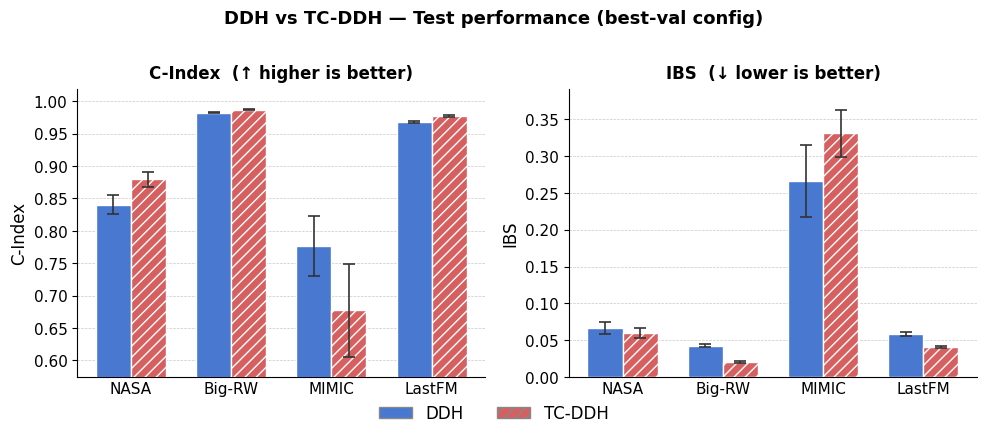

In [11]:
import matplotlib.patches as mpatches

def summary_comparison_plot(df, save_path=None):
    """
    Conference-grade grouped bar chart comparing DDH vs TC-DDH across all datasets.
    For each dataset: baseline = DDH (all seeds); TC = best (lambda, target_lr) by mean val metric.
    Error bars = std / sqrt(n_seeds).
    """
    dataset_order  = ['nasa', 'big_rw', 'mimic', 'churn_lastfm_months']
    dataset_labels = {'nasa': 'NASA', 'big_rw': 'Big-RW', 'mimic': 'MIMIC', 'churn_lastfm_months': 'LastFM'}
    datasets = [d for d in dataset_order if d in df['dataset'].unique()]

    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.size': 11,
        'axes.linewidth': 0.8, 'pdf.fonttype': 42,
    })

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    bar_w  = 0.35
    x      = np.arange(len(datasets))
    clr    = {'DDH': '#4878CF', 'TC-DDH': '#D65F5F'}
    hatch  = {'DDH': '',        'TC-DDH': '///'}

    metrics = [
        ('ci',  'val_ci',  'test_ci',  'C-Index',    True),
        ('ibs', 'val_ibs', 'test_ibs', 'IBS',        False),
    ]

    for ax, (metric_key, val_col, test_col, ylabel, higher_better) in zip(axes, metrics):
        base_means, base_errs = [], []
        tc_means,   tc_errs   = [], []

        for dataset in datasets:
            dset = df[df['dataset'] == dataset]

            # ── Baseline: DDH ────────────────────────────────────────────────
            ddh_scores = dset[dset['algorithm'] == 'DDH'][test_col].dropna().values
            base_means.append(ddh_scores.mean() if len(ddh_scores) else np.nan)
            base_errs.append(ddh_scores.std() / np.sqrt(len(ddh_scores)) if len(ddh_scores) > 1 else 0)

            # ── TC: pick best config by mean val metric ──────────────────────
            ddh_tc = dset[dset['algorithm'] == 'DDH_TC']
            if len(ddh_tc) == 0:
                tc_means.append(np.nan); tc_errs.append(0); continue
            agg = ddh_tc.groupby(['lambda_', 'target_lr'])[val_col].mean()
            bl, bt = agg.idxmax() if higher_better else agg.idxmin()
            best = ddh_tc[(ddh_tc['lambda_'] == bl) & (ddh_tc['target_lr'] == bt)][test_col].dropna().values
            tc_means.append(best.mean() if len(best) else np.nan)
            tc_errs.append(best.std() / np.sqrt(len(best)) if len(best) > 1 else 0)

        ekw = dict(elinewidth=1.2, ecolor='#333333', capthick=1.2)
        ax.bar(x - bar_w/2, base_means, bar_w, yerr=base_errs, capsize=4,
               color=clr['DDH'],    hatch=hatch['DDH'],    label='DDH',
               edgecolor='white', error_kw=ekw, zorder=3)
        ax.bar(x + bar_w/2, tc_means, bar_w, yerr=tc_errs, capsize=4,
               color=clr['TC-DDH'], hatch=hatch['TC-DDH'], label='TC-DDH',
               edgecolor='white', error_kw=ekw, zorder=3)

        ax.set_xticks(x)
        ax.set_xticklabels([dataset_labels.get(d, d) for d in datasets], fontsize=11)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(axis='x', length=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        arrow = '↑ higher is better' if higher_better else '↓ lower is better'
        ax.set_title(f'{ylabel}  ({arrow})', fontsize=12, fontweight='bold', pad=8)

        # y-range with a small margin
        vals = [v for v in base_means + tc_means if not np.isnan(v)]
        errs = base_errs + tc_errs
        if vals:
            lo = min(v - e for v, e in zip(base_means + tc_means, errs) if not np.isnan(v))
            hi = max(v + e for v, e in zip(base_means + tc_means, errs) if not np.isnan(v))
            pad = (hi - lo) * 0.08
            ax.set_ylim(max(0, lo - pad), hi + pad)

    handles = [
        mpatches.Patch(facecolor=clr['DDH'],    label='DDH',    edgecolor='#888'),
        mpatches.Patch(facecolor=clr['TC-DDH'], label='TC-DDH', hatch='///', edgecolor='#888'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
               fontsize=12, bbox_to_anchor=(0.5, -0.06))
    fig.suptitle('DDH vs TC-DDH — Test performance (best-val config)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()

summary_comparison_plot(df, save_path='../summary_DDH.pdf')
